In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df_sfpl = pd.read_csv("/home/tim/Schreibtisch/2024-25-Data_Librarian-Reschop_Tim/Modul_3/Data/Library_Usage_Clean.csv")
df_sfpl

/tmp/ipykernel_4163/3549142085.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sfpl = pd.read_csv("/home/tim/Schreibtisch/2024-25-Data_Librarian-Reschop_Tim/Modul_3/Data/Library_Usage_Clean.csv")


,Unnamed: 0,Patron Type Definition,Total Checkouts,Total Renewals,Age Range,Home Library Definition,Circulation Active Month,Circulation Active Year,Notice Preference Definition,Provided Email Address,Year Patron Registered,Within San Francisco County,Membership Duration
0,0,Senior,5,0,75 years and over,Main,1900-11-01,2022.0,Email,True,2022.0,False,11.0
1,1,Adult,0,0,45 to 54 years,Main,1900-07-01,2023.0,Email,True,2023.0,False,7.0
2,2,Adult,0,0,55 to 59 years,Western Addition,1900-03-01,2024.0,Email,True,2024.0,False,3.0
3,3,Welcome,1,1,20 to 24 years,Richmond,1900-08-01,2022.0,Email,True,2022.0,False,8.0
4,4,Senior,0,0,65 to 74 years,Sunset,1900-03-01,2024.0,Print,False,2024.0,False,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
450354,450354,Digital Access Card,0,0,35 to 44 years,Ingleside,NaN,NaN,Email,False,NaN,Null,0.0
450355,450355,Digital Access Card,0,0,45 to 54 years,Ingleside,1900-08-01,2022.0,Print,False,2022.0,Null,8.0
450356,450356,Digital Access Card,0,0,25 to 34 years,Ingleside,1900-08-01,2022.0,Print,False,2022.0,Null,8.0
450357,450357,Digital Access Card,0,0,35 to 44 years,Ingleside,1900-04-01,2022.0,Print,False,2022.0,Null,4.0


<font color='red'>AL: Dein Zielverzeichnis habe ich nicht, daher:</font>

In [7]:
df_sfpl = pd.read_csv("../data/Library_Usage_Clean.csv", low_memory=False)
df_sfpl

,Patron Type Definition,Total Checkouts,Total Renewals,Age Range,Home Library Definition,Circulation Active Month,Circulation Active Year,Notice Preference Definition,Provided Email Address,Year Patron Registered,Within San Francisco County
0,Senior,5,0,75 years and over,Main,Nov,2022.0,Email,True,2015,False
1,Adult,0,0,45 to 54 years,Main,Jul,2023.0,Email,True,2019,False
2,Adult,0,0,55 to 59 years,Western Addition,Mar,2024.0,Email,True,2022,False
3,Welcome,1,1,20 to 24 years,Richmond,Aug,2022.0,Email,True,2022,False
4,Senior,0,0,65 to 74 years,Sunset,Mar,2024.0,Print,False,2023,False
...,...,...,...,...,...,...,...,...,...,...,...
406988,Adult,0,0,35 to 44 years,Main,Jan,2020.0,Phone,False,2020,False
406989,Adult,0,0,45 to 54 years,Main,Mar,2024.0,Email,True,2017,False
406990,Adult,0,0,60 to 64 years,Main,Dec,2023.0,Email,True,2019,False
406991,Adult,0,0,25 to 34 years,Main,Jan,2021.0,Email,True,2019,False


In [8]:
#1 Bereinigung
#1.1 Bereinigung des Datensatzen und Ersetzen der fehlenden Werte mit dem Median, in den Spalten "Total Checkouts" und "Total Renewals"
    #Der Median ist im Gegensatz zum arithmetischen Mittel weniger anfällig für Ausreißer, weshalb ich mich dafür entschieden habe. 
    #Bei den Spalten "Age Range und Home Library Definition habe ich mich dafür entschieden, mit dropna() fehlende Werte zu entfernen, da ich
    #mit diesen Spalten unter anderem Arbeiten möchte und meiner Meinung nach keine sinnvollen "Ersatzbeobachtungen" einfügen kann.

df_sfpl["Total Checkouts"].fillna(df_sfpl["Total Checkouts"].median(), inplace=True)
df_sfpl["Total Renewals"].fillna(df_sfpl["Total Renewals"].median(), inplace=True)
df_sfpl_cleaned = df_sfpl.dropna(subset=["Age Range", "Home Library Definition"])
df_sfpl_cleaned

,Patron Type Definition,Total Checkouts,Total Renewals,Age Range,Home Library Definition,Circulation Active Month,Circulation Active Year,Notice Preference Definition,Provided Email Address,Year Patron Registered,Within San Francisco County
0,Senior,5,0,75 years and over,Main,Nov,2022.0,Email,True,2015,False
1,Adult,0,0,45 to 54 years,Main,Jul,2023.0,Email,True,2019,False
2,Adult,0,0,55 to 59 years,Western Addition,Mar,2024.0,Email,True,2022,False
3,Welcome,1,1,20 to 24 years,Richmond,Aug,2022.0,Email,True,2022,False
4,Senior,0,0,65 to 74 years,Sunset,Mar,2024.0,Print,False,2023,False
...,...,...,...,...,...,...,...,...,...,...,...
406988,Adult,0,0,35 to 44 years,Main,Jan,2020.0,Phone,False,2020,False
406989,Adult,0,0,45 to 54 years,Main,Mar,2024.0,Email,True,2017,False
406990,Adult,0,0,60 to 64 years,Main,Dec,2023.0,Email,True,2019,False
406991,Adult,0,0,25 to 34 years,Main,Jan,2021.0,Email,True,2019,False


<font color='red'>AL: Schöne Erklärung, was Du warum gemacht hast (auch wenn der Datensatz schon sehr sauber war)</font>

In [9]:
#Offensichtlich waren im Datensatz keine fehlenden Werte für die Columns "Age Range" und "Home Library Definition",
#da die Anzahl der Zeilen gleich geblieben ist.

#1.2 Positive Ausreißer entfernen mit IQR-Methode
# Interquartilsabstand (IQR) berechnen
Q1_checkouts = df_sfpl_cleaned["Total Checkouts"].quantile(0.25)
Q3_checkouts = df_sfpl_cleaned["Total Checkouts"].quantile(0.75)
IQR_checkouts = Q3_checkouts - Q1_checkouts

Q1_renewals = df_sfpl_cleaned["Total Renewals"].quantile(0.25)
Q3_renewals = df_sfpl_cleaned["Total Renewals"].quantile(0.75)
IQR_renewals = Q3_renewals - Q1_renewals

# Oberes Limit für Ausreißer: Q3 + 1.5 * IQR
upper_limit_checkouts = Q3_checkouts + 1.5 * IQR_checkouts
upper_limit_renewals = Q3_renewals + 1.5 * IQR_renewals

# Entferne alle Beobachtungen, die über diesem Grenzwert liegen
df_sfpl_filtered = df_sfpl_cleaned[
    (df_sfpl_cleaned["Total Checkouts"] <= upper_limit_checkouts) &
    (df_sfpl_cleaned["Total Renewals"] <= upper_limit_renewals)
]
df_sfpl_filtered

,Patron Type Definition,Total Checkouts,Total Renewals,Age Range,Home Library Definition,Circulation Active Month,Circulation Active Year,Notice Preference Definition,Provided Email Address,Year Patron Registered,Within San Francisco County
0,Senior,5,0,75 years and over,Main,Nov,2022.0,Email,True,2015,False
1,Adult,0,0,45 to 54 years,Main,Jul,2023.0,Email,True,2019,False
2,Adult,0,0,55 to 59 years,Western Addition,Mar,2024.0,Email,True,2022,False
3,Welcome,1,1,20 to 24 years,Richmond,Aug,2022.0,Email,True,2022,False
4,Senior,0,0,65 to 74 years,Sunset,Mar,2024.0,Print,False,2023,False
...,...,...,...,...,...,...,...,...,...,...,...
406988,Adult,0,0,35 to 44 years,Main,Jan,2020.0,Phone,False,2020,False
406989,Adult,0,0,45 to 54 years,Main,Mar,2024.0,Email,True,2017,False
406990,Adult,0,0,60 to 64 years,Main,Dec,2023.0,Email,True,2019,False
406991,Adult,0,0,25 to 34 years,Main,Jan,2021.0,Email,True,2019,False


In [10]:
#2. Statsitische Analyse
    #Nun sollen folgende Fragestellung mit Statistischen Berechnungen bearbeitet werden:
    #1. Wie viele Ausleihen gibt es durchschnittlich pro Altersgruppe?
    #2. Welche Bibliotheken haben die höchste Nutzerzahl? Welche die höchste Aktivität?
    #3. Wie viele Nutzer gibt es innerhalb/außerhalb von San Francisco und zu welcher Altersgruppe gehören sie?

In [11]:
#2.1 Wie  Nutzer gibt es pro Altersgruppe und wie viele Ausleihen gibt es durchschnittlich pro Altersgruppe?

# Anzahl der Nutzer pro Altersgruppe berechnen
age_group_counts = df_sfpl_filtered["Age Range"].value_counts().reset_index()
age_group_counts.columns = ["Age Range", "Number of Users"]

# Durchschnittliche Anzahl an Ausleihen pro Altersgruppe berechnen
age_group_checkouts = df_sfpl_filtered.groupby("Age Range")["Total Checkouts"].mean().reset_index()
age_group_checkouts.columns = ["Age Range", "Average Checkouts"]

# Ergebnisse mit display ausgeben
from IPython.display import display

print("Anzahl der Nutzer pro Altersgruppe:")
display(age_group_counts)

print("\nDurchschnittliche Anzahl an Ausleihen pro Altersgruppe:")
display(age_group_checkouts)


Anzahl der Nutzer pro Altersgruppe:


,Age Range,Number of Users
0,25 to 34 years,82899
1,35 to 44 years,70429
2,10 to 19 years,41808
3,45 to 54 years,36383
4,65 to 74 years,21679
5,20 to 24 years,19553
6,0 to 9 years,16293
7,55 to 59 years,13842
8,75 years and over,12661
9,60 to 64 years,12509



Durchschnittliche Anzahl an Ausleihen pro Altersgruppe:


,Age Range,Average Checkouts
0,0 to 9 years,28.135580
1,10 to 19 years,41.275402
2,20 to 24 years,23.060963
3,25 to 34 years,12.164622
4,35 to 44 years,19.507476
5,45 to 54 years,27.973779
6,55 to 59 years,28.805230
7,60 to 64 years,27.625630
8,65 to 74 years,28.522441
9,75 years and over,35.032857


In [12]:
#Hier zeigt sich, dass die Altersgruppen 10-19 und über 75 Jahre im Durchschnitt die meisten Ausleihen tätigen. 
#Die Gruppe der über 75-Jährigen ist zudem die kleinste Nutzergruppe, verzeichnet aber die zweitmeisten Ausleihen, 
#was evtl. mit der verfügbaren Zeit der Altergruppen (Schüler:innen und Rentner:innen im Gegensatz zu Berufstätigen oder Kindern, 
#die erst seit kurzem Lesen können) zusammenhängt. 

<font color='red'>AL: Schöne Erklärung und Interpretation </font>

In [13]:
# 2.2. Welche Bibliotheken haben die höchste Nutzerzahl? Welche die höchste Aktivität?

# Ranking der Bibliotheken nach Nutzerzahl
library_user_counts = df_sfpl_filtered["Home Library Definition"].value_counts().reset_index()
library_user_counts.columns = ["Home Library", "Number of Users"]

# Ranking der Bibliotheken nach durchschnittlicher Aktivität (Ausleihen + Verlängerungen)
library_activity = df_sfpl_filtered.groupby("Home Library Definition")[["Total Checkouts", "Total Renewals"]].mean().reset_index()
library_activity["Total Activity"] = library_activity["Total Checkouts"] + library_activity["Total Renewals"]
library_activity = library_activity.sort_values(by="Total Activity", ascending=False)

# Ergebnisse mit display ausgeben

print("Ranking der Bibliotheken nach Nutzerzahl:")
display(library_user_counts)

print("\nRanking der Bibliotheken nach Aktivität (Ausleihen + Verlängerungen):")
display(library_activity)


Ranking der Bibliotheken nach Nutzerzahl:


,Home Library,Number of Users
0,Main,105371
1,Richmond,14638
2,Mission Bay,14271
3,Mission,14064
4,Sunset,10489
5,Ortega,9917
6,Eureka Valley,9743
7,Park,9710
8,Marina,9688
9,Excelsior,9389



Ranking der Bibliotheken nach Aktivität (Ausleihen + Verlängerungen):


,Home Library Definition,Total Checkouts,Total Renewals,Total Activity
18,Ortega,40.011294,18.869416,58.880710
21,Portola,41.352366,16.016283,57.368650
27,West Portal,39.234680,17.878401,57.113081
7,Glen Park,37.798737,18.811028,56.609764
24,Richmond,33.457781,17.012638,50.470419
6,Excelsior,34.737246,13.921397,48.658643
9,Ingleside,32.923620,15.582157,48.505777
4,Chinatown,34.463954,13.758065,48.222019
2,Bernal Heights,31.467381,15.890603,47.357984
15,Noe Valley,30.434422,16.689542,47.123964


In [ ]:
#Das Ergebnis zeigt, dass die Bibliotheken mit den größten Nutzerzahlen nicht zwangsläufig die größte Aktivität aufweisen. 
#Die Frage ist, was unter Checkouts und Renewals gelistet wird: Auch e-Ressourcen? 
#Hat eine Bibliothek also evtl. mehr Nutzer:innen aber viel weniger Ausleihen und Verlängerungen, weil sie deutlich mehr e-Medien anbietet?

<font color='red'>AL: s.o.</font>

In [14]:
# 2.3. Wie viele Nutzer gibt es innerhalb/außerhalb von San Francisco und zu welcher Altersgruppe gehören sie?

# Anzahl der Nutzer innerhalb & außerhalb von San Francisco
location_counts = df_sfpl_filtered["Within San Francisco County"].value_counts().reset_index()
location_counts.columns = ["Within San Francisco", "Number of Users"]

# Altersgruppenverteilung nach Wohnort
location_age_distribution = df_sfpl_filtered.groupby(["Within San Francisco County", "Age Range"]).size().unstack().fillna(0)

print("Nutzer innerhalb und außerhalb von San Francisco:")
display(location_counts)

print("\nAltersgruppenverteilung nach Wohnort:")
display(location_age_distribution)

Nutzer innerhalb und außerhalb von San Francisco:


,Within San Francisco,Number of Users
0,True,268047
1,False,60009



Altersgruppenverteilung nach Wohnort:


Age Range,0 to 9 years,10 to 19 years,20 to 24 years,25 to 34 years,35 to 44 years,45 to 54 years,55 to 59 years,60 to 64 years,65 to 74 years,75 years and over
Within San Francisco County,,,,,,,,,,
False,725,3543,3423,12596,13022,8893,3727,3701,6910,3469
True,15568,38265,16130,70303,57407,27490,10115,8808,14769,9192


In [15]:
#Anpassung der True / False Werte, damit eine einheitliche Tabelle ausgegeben wird

# Sicherstellen, dass die Werte konsistent als True/False gespeichert werden
df_sfpl_filtered["Within San Francisco County"] = df_sfpl_filtered["Within San Francisco County"].astype(str).str.strip()
df_sfpl_filtered["Within San Francisco County"] = df_sfpl_filtered["Within San Francisco County"].replace({
    "TRUE": True, "True": True, "FALSE": False, "False": False, "null": None, "NULL": None, "NaN": None
})

# Fehlende Werte entfernen, falls gewünscht
df_sfpl_filtered = df_sfpl_filtered.dropna(subset=["Within San Francisco County"])

# Anzahl der Nutzer innerhalb & außerhalb von San Francisco
location_counts = df_sfpl_filtered["Within San Francisco County"].value_counts().reset_index()
location_counts.columns = ["Within San Francisco", "Number of Users"]

# Altersgruppenverteilung nach Wohnort
location_age_distribution = df_sfpl_filtered.groupby(["Within San Francisco County", "Age Range"]).size().unstack().fillna(0)


print("Nutzer innerhalb und außerhalb von San Francisco:")
display(location_counts)

print("\nAltersgruppenverteilung nach Wohnort:")
display(location_age_distribution)


Nutzer innerhalb und außerhalb von San Francisco:


/var/folders/xc/0ys6f7w12cq2dq1xqlg9nmcm0000gn/T/ipykernel_27360/2475316761.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sfpl_filtered["Within San Francisco County"] = df_sfpl_filtered["Within San Francisco County"].astype(str).str.strip()
/var/folders/xc/0ys6f7w12cq2dq1xqlg9nmcm0000gn/T/ipykernel_27360/2475316761.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sfpl_filtered["Within San Francisco County"] = df_sfpl_filtered["Within San Francisco County"].replace({


,Within San Francisco,Number of Users
0,True,268047
1,False,60009



Altersgruppenverteilung nach Wohnort:


Age Range,0 to 9 years,10 to 19 years,20 to 24 years,25 to 34 years,35 to 44 years,45 to 54 years,55 to 59 years,60 to 64 years,65 to 74 years,75 years and over
Within San Francisco County,,,,,,,,,,
False,725,3543,3423,12596,13022,8893,3727,3701,6910,3469
True,15568,38265,16130,70303,57407,27490,10115,8808,14769,9192


/var/folders/xc/0ys6f7w12cq2dq1xqlg9nmcm0000gn/T/ipykernel_27360/482905735.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_group_checkouts, y="Average Checkouts", x="Age Range", palette="Blues_d")


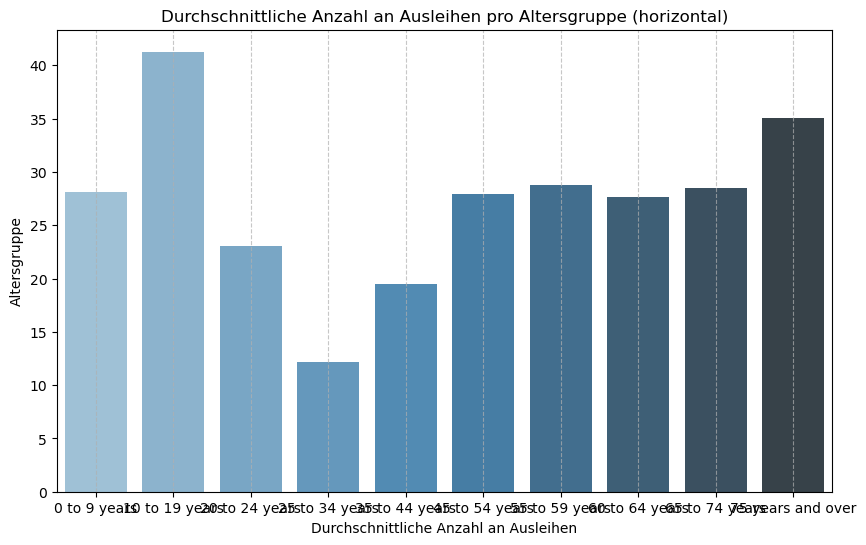

In [16]:
# 3. Visualisierungen
    #3.1. Durchschnittliche Anzahl an Ausleihen pro Altersgruppe (Säulendiagramm)
    #3.2. Durchschnittliche Anzhal an Ausleihen pro Bibliothek (Balkendiagramm)
    #3.3. Anzahl der gesamten Ausleihen aller Bibliotheken über einen bestimmten Zeitraum (Liniendiagramm)

#3.1. Wie viele Ausleihen gibt es durchschnittlich pro Altersgruppe? (Säulendiagramm)

plt.figure(figsize=(10, 6))
sns.barplot(data=age_group_checkouts, y="Average Checkouts", x="Age Range", palette="Blues_d")
plt.xlabel("Durchschnittliche Anzahl an Ausleihen")
plt.ylabel("Altersgruppe")
plt.title("Durchschnittliche Anzahl an Ausleihen pro Altersgruppe (horizontal)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


<font color='red'>AL: Die Beschriftung der Achsen ist verkehrt. Die x-Achse stellt die Altersgruppe dar, 
    die y-Achse die durchschnittliche Anzahl an Ausleihen</font>

/var/folders/xc/0ys6f7w12cq2dq1xqlg9nmcm0000gn/T/ipykernel_27360/1556432715.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=library_stats, y="Home Library Definition", x="Total Checkouts", palette="Greens_d")


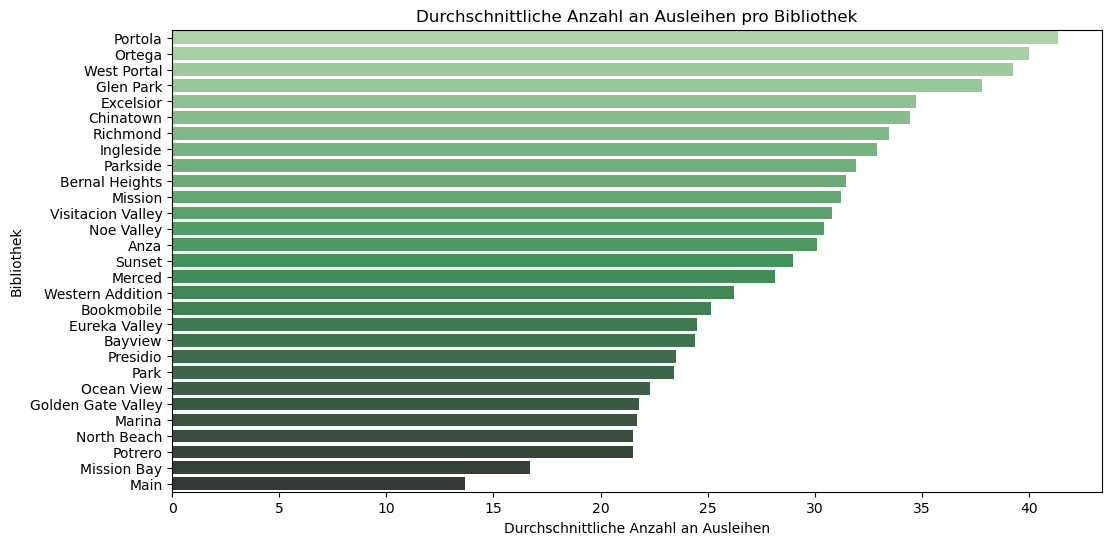

In [17]:
# 3.2. Wie viele Ausleihen gibt es durchschnittlich pro Bibliothek? (Balkendiagramm)

library_stats = df_sfpl_filtered.groupby("Home Library Definition")["Total Checkouts"].mean().reset_index()
library_stats = library_stats.sort_values("Total Checkouts", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=library_stats, y="Home Library Definition", x="Total Checkouts", palette="Greens_d")
plt.xlabel("Durchschnittliche Anzahl an Ausleihen")
plt.ylabel("Bibliothek")
plt.title("Durchschnittliche Anzahl an Ausleihen pro Bibliothek")
plt.show()



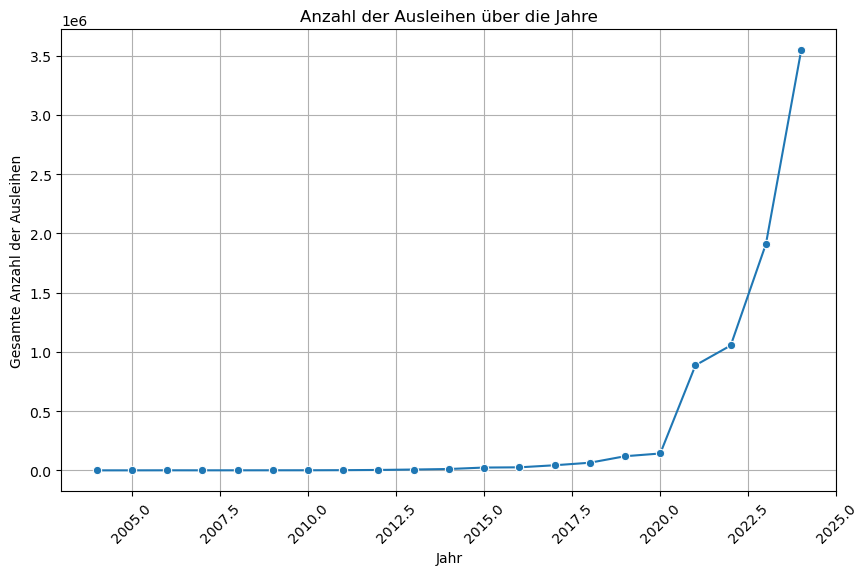

In [18]:
# 3.3. Wie Verändert sich die Anzahl der Ausleihen über die Jahre? (Liniendiagramm)

# Anzahl der Ausleihen pro Jahr aggregieren, da sie so noch nicht als Variable im Datensatz exisitiert
checkout_trend = df_sfpl_filtered.groupby("Circulation Active Year")["Total Checkouts"].sum().reset_index()

# Liniendiagramm erstellen
plt.figure(figsize=(10, 6))
sns.lineplot(data=checkout_trend, x="Circulation Active Year", y="Total Checkouts", marker="o")
plt.xlabel("Jahr")
plt.ylabel("Gesamte Anzahl der Ausleihen")
plt.title("Anzahl der Ausleihen über die Jahre")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


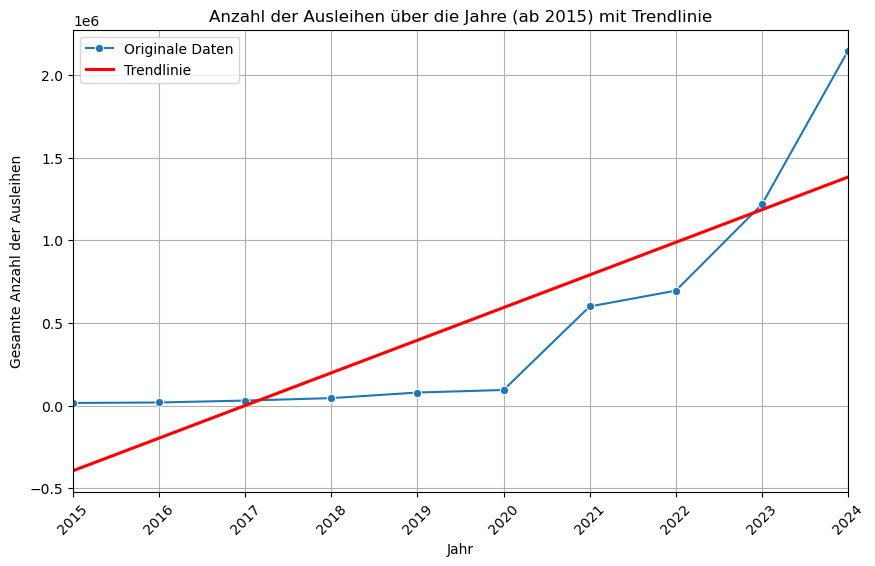

In [48]:
#Einschränken des Diagramms auf einen relevanten Zeitraum ab 2015
#Offensichtlich steigen die Ausleihen über die Jahre stark an. Woran das genau liegt, kann aus den Daten heraus nicht erklärt werden.

# Filtern der Daten auf Jahre ab 2015
df_sfpl_filtered_years = df_sfpl_filtered[df_sfpl_filtered["Circulation Active Year"] >= 2015]

# Anzahl der Ausleihen pro Jahr aggregieren
checkout_trend = df_filtered_years.groupby("Circulation Active Year")["Total Checkouts"].sum().reset_index()

# Liniendiagramm
plt.figure(figsize=(10, 6))

# Originale Zeitreihe der Anzahl der Ausleihen als Linie
sns.lineplot(data=checkout_trend, x="Circulation Active Year", y="Total Checkouts", marker="o", label="Originale Daten")

# Trendlinie mit Seaborn
sns.regplot(data=checkout_trend, x="Circulation Active Year", y="Total Checkouts", scatter=False, color="red", ci=None, label="Trendlinie")

# Achsenbeschriftungen & Titel
plt.xlabel("Jahr")
plt.ylabel("Gesamte Anzahl der Ausleihen")
plt.title("Anzahl der Ausleihen über die Jahre (ab 2015) mit Trendlinie")
plt.xticks(rotation=45)

# X-Achse begrenzen
plt.xlim(2015, checkout_trend["Circulation Active Year"].max())

# Gitterlinien für bessere Lesbarkeit
plt.grid(True)
plt.legend()

# Diagramm anzeigen
plt.show()



<font color='red'>AL: Insgesamt schön bearbeitet!</font>